In [3]:
# 1. Instalar dependências
!pip install -q torch torchvision matplotlib tqdm


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [4]:
# 2. Imports
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm import tqdm

In [7]:
# 3. Carregar o dataset PCam
transform_base = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.PCAM(
    root="./data",
    split="train",
    download=True,
    transform=transform_base
)

test_dataset = torchvision.datasets.PCAM(
    root="./data",
    split="test",
    download=True,
    transform=transform_base
)

print("Train:", len(train_dataset))
print("Test:", len(test_dataset))

Downloading...
From (original): https://drive.google.com/uc?id=1Ka0XfEMiwgCYPdTI-vv6eUElOBnKFKQ2
From (redirected): https://drive.usercontent.google.com/download?id=1Ka0XfEMiwgCYPdTI-vv6eUElOBnKFKQ2&confirm=t&uuid=109cdef5-5891-4e68-9d1b-d6e1cdaf7cf6
To: /home/carolina/post_medium /data/pcam/camelyonpatch_level_2_split_train_x.h5.gz
100%|██████████| 6.42G/6.42G [03:42<00:00, 28.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1269yhu3pZDP8UYFQs-NYs3FPwuK-nGSG
To: /home/carolina/post_medium /data/pcam/camelyonpatch_level_2_split_train_y.h5.gz
100%|██████████| 21.4k/21.4k [00:00<00:00, 26.0MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1qV65ZqZvWzuIVthK8eVDhIwrbnsJdbg_
From (redirected): https://drive.usercontent.google.com/download?id=1qV65ZqZvWzuIVthK8eVDhIwrbnsJdbg_&confirm=t&uuid=546c2fc6-1798-4b0f-8d48-2db540f0cb5c
To: /home/carolina/post_medium /data/pcam/camelyonpatch_level_2_split_test_x.h5.gz
100%|██████████| 801M/801M [00:30<00:00, 26.5MB/s] 
Dow

Train: 262144
Test: 32768


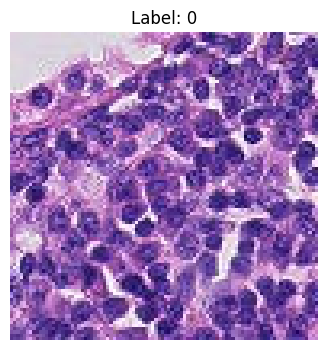

In [8]:
# 4. Visualizar uma imagem
image, label = train_dataset[0]

plt.figure(figsize=(4,4))
plt.imshow(image.permute(1, 2, 0))
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

In [9]:
# 5. Funções de zoom in e zoom out

def zoom_in_pil(img, crop_fraction=0.6):
    """
    Corta o centro da imagem e redimensiona de volta.
    """
    w, h = img.size

    crop_w = int(w * crop_fraction)
    crop_h = int(h * crop_fraction)

    left = (w - crop_w) // 2
    top = (h - crop_h) // 2
    right = left + crop_w
    bottom = top + crop_h

    cropped = img.crop((left, top, right, bottom))
    zoomed = cropped.resize((w, h))

    return zoomed


def zoom_out_pil(img, scale=0.6):
    """
    Reduz a imagem e coloca em um canvas preto.
    """
    w, h = img.size

    new_w = int(w * scale)
    new_h = int(h * scale)

    small = img.resize((new_w, new_h))

    canvas = Image.new("RGB", (w, h), (0, 0, 0))

    left = (w - new_w) // 2
    top = (h - new_h) // 2

    canvas.paste(small, (left, top))

    return canvas

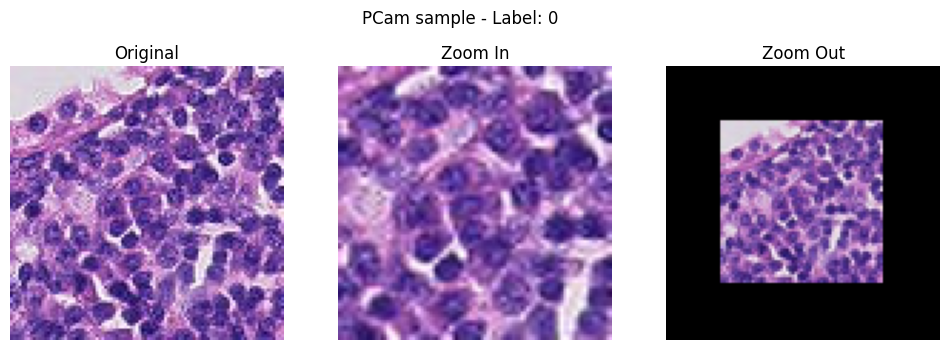

In [10]:
# 6. Visualizar original, zoom in e zoom out

# pegar imagem em PIL diretamente sem transform
raw_dataset = torchvision.datasets.PCAM(
    root="./data",
    split="train",
    download=False,
    transform=None
)

img_pil, label = raw_dataset[0]

img_zi = zoom_in_pil(img_pil, crop_fraction=0.6)
img_zo = zoom_out_pil(img_pil, scale=0.6)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img_pil)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(img_zi)
plt.title("Zoom In")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(img_zo)
plt.title("Zoom Out")
plt.axis("off")

plt.suptitle(f"PCam sample - Label: {label}")
plt.show()

In [11]:
# 7. ResNet50 pré-treinada para embeddings

import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

weights = ResNet50_Weights.IMAGENET1K_V2
resnet = resnet50(weights=weights)

# remover a última camada de classificação
resnet.fc = nn.Identity()

resnet = resnet.to(device)
resnet.eval()

/home/carolina/post_medium /venv/lib/python3.12/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Device: cpu
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/carolina/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 61.5MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [12]:
# 8. Transformação para ResNet50

resnet_transform = weights.transforms()

In [13]:
# 9. Gerar embeddings para original, zoom in e zoom out

images = [
    resnet_transform(img_pil),
    resnet_transform(img_zi),
    resnet_transform(img_zo)
]

batch = torch.stack(images).to(device)

with torch.no_grad():
    embeddings = resnet(batch)

print("Formato dos embeddings:", embeddings.shape)

Formato dos embeddings: torch.Size([3, 2048])


In [14]:
# 10. Concatenar embeddings multi-escala

original_emb = embeddings[0]
zoom_in_emb = embeddings[1]
zoom_out_emb = embeddings[2]

multi_scale_embedding = torch.cat(
    [original_emb, zoom_in_emb, zoom_out_emb],
    dim=0
)

print("Embedding original:", original_emb.shape)
print("Embedding zoom in:", zoom_in_emb.shape)
print("Embedding zoom out:", zoom_out_emb.shape)
print("Embedding multi-escala:", multi_scale_embedding.shape)

Embedding original: torch.Size([2048])
Embedding zoom in: torch.Size([2048])
Embedding zoom out: torch.Size([2048])
Embedding multi-escala: torch.Size([6144])
